## Problem Statement
The goal of this task is to predict the next day closing price of Apple stock (AAPL) using historical stock data from Yahoo Finance. I used a Random Forest Regressor and Linear Regression models trained on features like Open, High, Low, Close, and Volume.

##### Import libraries

In [ ]:
import yfinance as yf #Fetch data from this API
import matplotlib.pyplot as plt #used to visualize graph of predicted and actual output
from sklearn.model_selection import train_test_split  #split the data intn train and test parts
from sklearn.linear_model import LinearRegression   #modes thats used for training
from sklearn.ensemble import RandomForestRegressor #model thats used for training

##### load the dataset from yahoofinance API

In [139]:
data=yf.download('AAPL',start="2020-1-1",end="2026-6-1")
data

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.333870,72.394078,71.091176,71.344047,135480400
2020-01-03,71.630646,72.389265,71.406674,71.563213,146322800
2020-01-06,72.201408,72.239942,70.503546,70.754014,118387200
2020-01-07,71.861839,72.466322,71.642681,72.211041,108872000
2020-01-08,73.017815,73.318854,71.565599,71.565599,132079200
...,...,...,...,...,...
2026-05-22,308.820007,311.399994,305.839996,306.119995,43670200
2026-05-26,308.329987,311.820007,307.670013,309.559998,48000500


##### check the names of columns

In [ ]:
data.columns 

MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])

##### Check the structure of the data

In [141]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1610 entries, 2020-01-02 to 2026-05-29
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1610 non-null   float64
 1   (High, AAPL)    1610 non-null   float64
 2   (Low, AAPL)     1610 non-null   float64
 3   (Open, AAPL)    1610 non-null   float64
 4   (Volume, AAPL)  1610 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 75.5 KB


##### use shift(-1) >>> add new column with target_close name in which data is shifted -1 from the close column


In [142]:

# Kal ki price ko naye column mai daal diya
data['Target_Close'] = data['Close'].shift(-1)
print(data)


Price            Close        High         Low        Open     Volume  \
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL   
Date                                                                    
2020-01-02   72.333870   72.394078   71.091176   71.344047  135480400   
2020-01-03   71.630646   72.389265   71.406674   71.563213  146322800   
2020-01-06   72.201408   72.239942   70.503546   70.754014  118387200   
2020-01-07   71.861839   72.466322   71.642681   72.211041  108872000   
2020-01-08   73.017815   73.318854   71.565599   71.565599  132079200   
...                ...         ...         ...         ...        ...   
2026-05-22  308.820007  311.399994  305.839996  306.119995   43670200   
2026-05-26  308.329987  311.820007  307.670013  309.559998   48000500   
2026-05-27  310.850006  313.260010  308.299988  308.329987   50430900   
2026-05-28  312.510010  312.799988  309.570007  310.679993   48220400   
2026-05-29  312.059998  315.000000  309.529999  311

##### use dropna >> remove the last line from the data bcz in last row target_close column value is nan

In [143]:
# NaN wali aakhri row ko saaf kar diya
data.dropna(inplace=True)

##### Fetaures and target variable thats used in training  

In [144]:
X_Features= data[['Open', 'High', 'Low', 'Close', 'Volume']] # these are the features in which model learns and then predict the target_close value

y = data['Target_Close'] # this will be predict

##### split the data into training and testing part

In [145]:

X_train, X_test, y_train, y_test = train_test_split(X_Features,y,test_size=0.2,random_state=42)

##### Model1 RandomForestRegressor

In [152]:
# Accuracy 99.52 of this model 

model1=RandomForestRegressor()  
model1.fit(X_train,y_train)



RandomForestRegressor()

##### Model2 LinearRegression

In [154]:
model2=LinearRegression()
model2.fit(X_train,y_train)  #Accuracy of this model is 99.59

LinearRegression()

##### Model predict on the basis of x_test data 

In [155]:
predict_Rf=model1.predict(X_test)
predict_Lr=model2.predict(X_test)

##### check the score 

In [159]:
score_model1 = model1.score(X_test, y_test)
print(f"Model_RandomForest Accuracy Score: {score_model1* 100:.2f}%")

score_model2 = model2.score(X_test, y_test)
print(f"Model_LinearRgressor Accuracy Score: {score_model2 * 100:.2f}%")



Model_RandomForest Accuracy Score: 99.52%
Model_LinearRgressor Accuracy Score: 99.59%


##### Graph >> Actual vs predicted

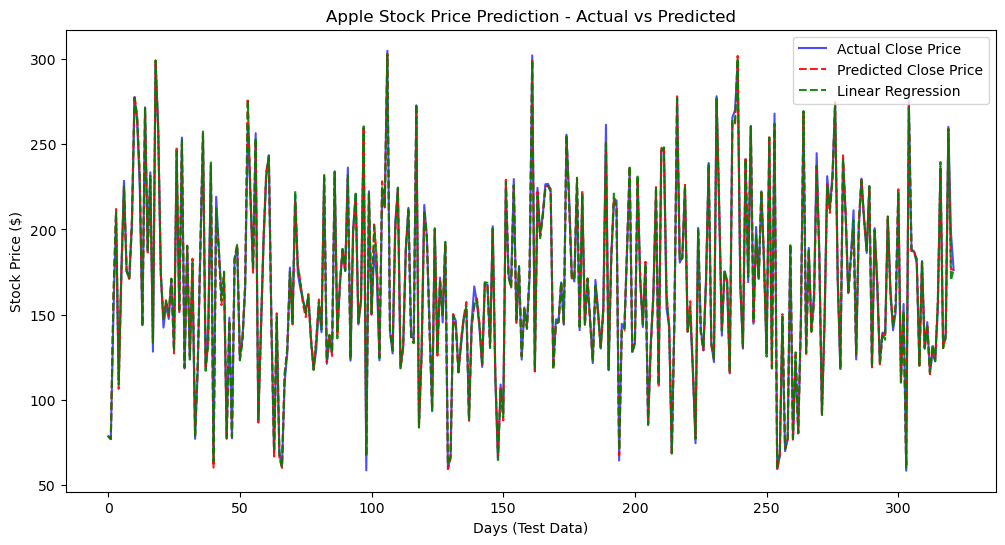

In [164]:

plt.figure(figsize=(12, 6))

# .values use kar rahe hain taake index ka masala na aaye aur graph saaf bane
plt.plot(y_test.values, label='Actual Close Price', color='blue', alpha=0.7)

# Model Randomforest  predicted prices  line (Red color)
plt.plot(predict_Rf, label='Predicted Close Price', color='red', linestyle='--', alpha=0.9)

# Model Linear Regressor predicted prices  line (Red color)
plt.plot(predict_Lr, label='Linear Regression', color='green', linestyle='--',alpha=0.9)


# Labels and titles
plt.title('Apple Stock Price Prediction - Actual vs Predicted')
plt.xlabel('Days (Test Data)')
plt.ylabel('Stock Price ($)')
plt.legend() 
plt.show()

## Final Insights
- Both Linear Regression and Random Forest performed very well on this dataset
- Linear Regression achieved 99.59% R2 score while Random Forest achieved 99.52%
- Linear Regression slightly outperformed Random Forest which makes sense because stock prices have a strong linear relationship with their features like Open, High, Low
- The predicted prices follow the actual prices very closely as visible in the graph
- Overall both models are suitable for short term stock price prediction